In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

In [2]:
from google.colab import files

uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn (1).csv


In [3]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [7]:
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

df['TotalCharges'].fillna(
    df['TotalCharges'].median(),
    inplace=True
)

/tmp/ipykernel_2664/1321978346.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(


In [8]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


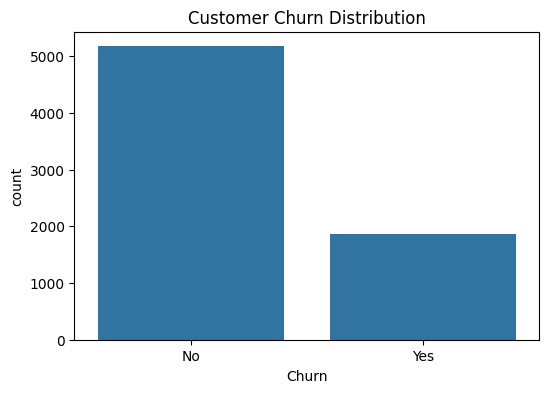

In [10]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Churn',
    data=df
)

plt.title("Customer Churn Distribution")

plt.savefig(
    "Churn_Distribution.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [11]:
from google.colab import files
files.download("Churn_Distribution.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

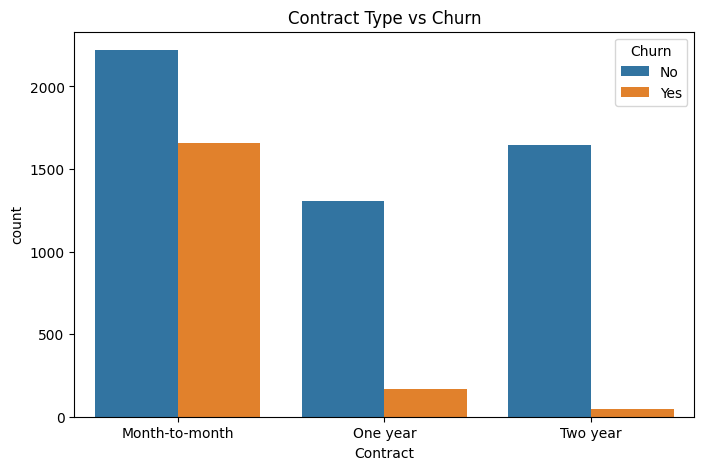

In [12]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Contract',
    hue='Churn',
    data=df
)

plt.title("Contract Type vs Churn")

plt.savefig(
    "Contract_vs_Churn.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [13]:
files.download("Contract_vs_Churn.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

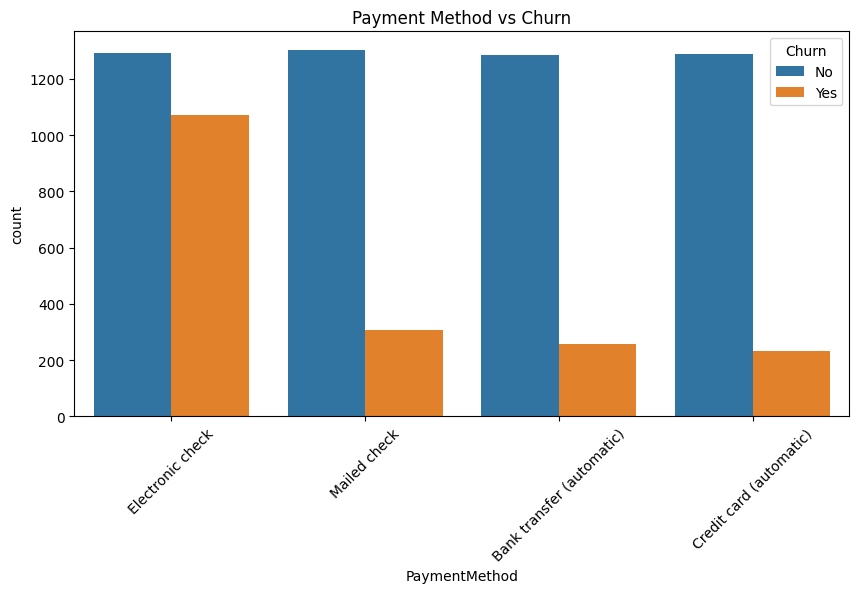

In [14]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='PaymentMethod',
    hue='Churn',
    data=df
)

plt.xticks(rotation=45)

plt.title("Payment Method vs Churn")

plt.savefig(
    "Payment_Method_vs_Churn.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [15]:
files.download("Payment_Method_vs_Churn.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

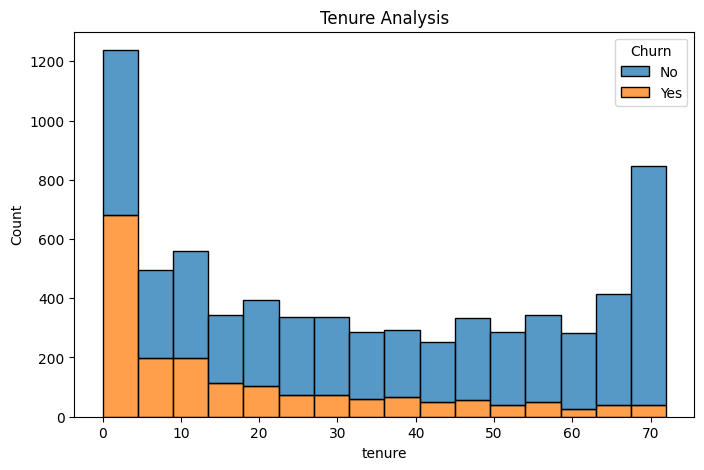

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='tenure',
    hue='Churn',
    multiple='stack'
)

plt.title("Tenure Analysis")

plt.savefig(
    "Tenure_Analysis.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [17]:
files.download("Tenure_Analysis.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

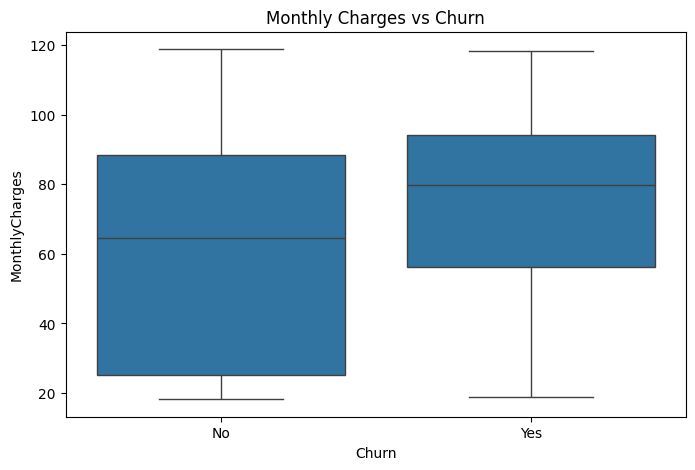

In [18]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Churn',
    y='MonthlyCharges',
    data=df
)

plt.title("Monthly Charges vs Churn")

plt.savefig(
    "Monthly_Charges_vs_Churn.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [19]:
files.download("Monthly_Charges_vs_Churn.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [20]:
import zipfile

with zipfile.ZipFile(
    'Customer_Churn_Graphs.zip',
    'w'
) as zipf:

    zipf.write('Churn_Distribution.png')
    zipf.write('Contract_vs_Churn.png')
    zipf.write('Payment_Method_vs_Churn.png')
    zipf.write('Tenure_Analysis.png')
    zipf.write('Monthly_Charges_vs_Churn.png')

from google.colab import files
files.download('Customer_Churn_Graphs.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [21]:
total_customers = len(df)

churned_customers = len(
    df[df['Churn'] == 'Yes']
)

churn_rate = (
    churned_customers /
    total_customers
) * 100

print("Total Customers:", total_customers)
print("Churned Customers:", churned_customers)
print("Churn Rate:", round(churn_rate, 2), "%")

Total Customers: 7043
Churned Customers: 1869
Churn Rate: 26.54 %


In [22]:
retained_customers = len(
    df[df['Churn'] == 'No']
)

retention_rate = (
    retained_customers /
    total_customers
) * 100

print("Retained Customers:", retained_customers)
print("Retention Rate:", round(retention_rate, 2), "%")

Retained Customers: 5174
Retention Rate: 73.46 %


In [23]:
avg_tenure = df['tenure'].mean()

print(
    "Average Customer Lifetime:",
    round(avg_tenure,2),
    "months"
)

Average Customer Lifetime: 32.37 months


In [24]:
summary = pd.DataFrame({
    'Metric': [
        'Total Customers',
        'Churned Customers',
        'Retained Customers',
        'Churn Rate (%)',
        'Retention Rate (%)',
        'Average Tenure'
    ],
    'Value': [
        total_customers,
        churned_customers,
        retained_customers,
        round(churn_rate,2),
        round(retention_rate,2),
        round(avg_tenure,2)
    ]
})

summary

,Metric,Value
0,Total Customers,7043.00
1,Churned Customers,1869.00
2,Retained Customers,5174.00
3,Churn Rate (%),26.54
4,Retention Rate (%),73.46
5,Average Tenure,32.37


In [25]:
summary.to_csv(
    "Customer_Churn_Summary.csv",
    index=False
)

print("Saved Successfully")

Saved Successfully


In [26]:
from google.colab import files

files.download(
    "Customer_Churn_Summary.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [27]:
insights = """
CUSTOMER RETENTION & CHURN ANALYSIS

Key Findings:

1. Month-to-Month contracts have highest churn.

2. Customers with shorter tenure are more likely to leave.

3. Electronic Check users show higher churn.

4. Customers with higher monthly charges churn more.

5. Average customer lifetime indicates retention opportunities.

Recommendations:

1. Promote yearly contracts.

2. Improve onboarding process.

3. Offer loyalty rewards.

4. Provide discounts to high-risk customers.

5. Encourage automatic payment methods.
"""

with open(
    "Insights.txt",
    "w"
) as file:
    file.write(insights)

In [28]:
files.download("Insights.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [29]:
df.to_csv(
    "Cleaned_Telco_Churn.csv",
    index=False
)

print("Dataset Saved")

Dataset Saved


In [30]:
files.download(
    "Cleaned_Telco_Churn.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>